In [ ]:
# Install hypertools (dev-2.0 preview) -- run this first on Colab.
# On release this becomes: %pip install hypertools
%pip install -q "hypertools[interactive] @ git+https://github.com/ContextLab/hypertools.git@dev-2.0"

# Mapping Wikipedia with modern text embeddings

Text embedding models map documents into high-dimensional vector spaces where
nearby vectors correspond to semantically related documents.  In this tutorial
we'll embed HyperTools' sample corpus of Wikipedia articles using a modern
text embedding model
([`BAAI/bge-small-en-v1.5`](https://huggingface.co/BAAI/bge-small-en-v1.5)),
untangle the embedding space with [UMAP](https://umap-learn.readthedocs.io),
discover article groupings with soft (Gaussian mixture) clustering, and
explore the resulting "map" of Wikipedia in 3D.

This tutorial uses one extra library that is *not* installed with HyperTools.
You can install it by running:

```
%pip install sentence-transformers
```

(The animation step at the end also uses [ffmpeg](https://ffmpeg.org) to
convert the exported movie into a GIF.)

In [1]:
%matplotlib inline
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_HUB_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from sentence_transformers import SentenceTransformer
from IPython.display import Image

import hypertools as hyp

## Loading the sample Wikipedia corpus

HyperTools ships with a sample corpus of Wikipedia articles, available through
`hyp.load('wiki')`.  The loader returns a `DataGeometry` object; calling its
`get_data` method returns the underlying array of documents, where each entry
is the (preprocessed) text of one Wikipedia article.

In [2]:
wiki = hyp.load('wiki')
articles = [str(doc) for doc in wiki.get_data()[0].ravel()]

print(f'number of articles: {len(articles)}')
print(f'average article length: {np.mean([len(a) for a in articles]):0.0f} characters')
print('\nfirst article (excerpt):\n', articles[0][:250], '...')

number of articles: 3136
average article length: 18048 characters

first article (excerpt):
 a gun salute is the most commonly recognized of the customary gun salutes that are performed by the firing of cannons or artillery as a military honorthe custom stems from naval tradition where a warship would fire its cannons harmlessly out to sea u ...


## Embedding the articles

We'll embed each article with
[`BAAI/bge-small-en-v1.5`](https://huggingface.co/BAAI/bge-small-en-v1.5), a
compact but powerful sentence-embedding model that maps each document onto a
384-dimensional vector.  The model reads at most 512 tokens per document, so
we truncate each article to its first 2,000 characters (roughly 512 tokens) --
this also speeds up encoding considerably, and the opening of a Wikipedia
article is nearly always a summary of the whole article anyway.

In [3]:
truncated = [a[:2000] for a in articles]

model = SentenceTransformer('BAAI/bge-small-en-v1.5')
embeddings = model.encode(truncated, batch_size=64, show_progress_bar=False)
embeddings.shape

(3136, 384)

## Mapping the corpus with UMAP and soft clustering

Now we can draw the map -- in a single call.  Passing `reduce='UMAP'`
projects the 384-dimensional embeddings down to 3D using UMAP, a nonlinear
method that is particularly good at untangling text embedding spaces.
Passing `cluster={'model': 'GaussianMixture', 'n_clusters': 10}` fits a
10-component Gaussian mixture model to the embeddings and colors each article
by its *blend* of cluster memberships, automatically: mixture models yield
soft assignments, and HyperTools renders each article's color as an exact
per-point blend of the cluster colors, weighted by that article's mixture
proportions.  Articles deep inside a cluster take on its pure color, while
articles between clusters get smoothly intermediate hues.  The `'.'` format
string together with `markersize=2` plots each article as a small dot.

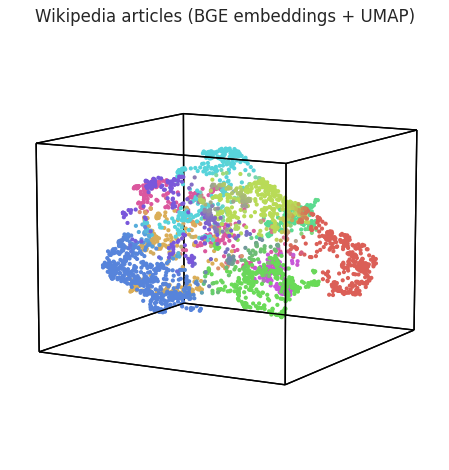

In [4]:
geo = hyp.plot(embeddings, '.', markersize=2, reduce='UMAP',
               cluster={'model': 'GaussianMixture', 'n_clusters': 10},
               title='Wikipedia articles (BGE embeddings + UMAP)')

Each dot is one Wikipedia article.  Articles about related topics form
clumps and filaments, and the blended colors show where topics shade into one
another.

## Taking a spin around the map

A static projection of a 3D point cloud always hides something.  Setting
`animate='spin'` slowly rotates the camera once around the map (over 10
seconds, at 30 frames per second) so we can inspect it from every angle.  We
export the animation as an MP4 -- compact and fast to render -- and then
convert it to a GIF with ffmpeg for inline display.

In [5]:
geo = hyp.plot(embeddings, '.', markersize=2, reduce='UMAP',
               cluster={'model': 'GaussianMixture', 'n_clusters': 10},
               animate='spin', duration=10, rotations=1, frame_rate=30,
               save_path='wikipedia_embeddings_spin.mp4', show=False)

print(f"mp4: {os.path.getsize('wikipedia_embeddings_spin.mp4')/1e6:0.1f} MB")

mp4: 2.3 MB


gif: 6.1 MB


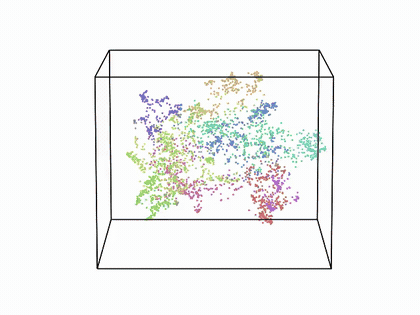

In [6]:
import shutil
import subprocess

if shutil.which('ffmpeg'):
    filters = ('fps=30,scale=420:-1:flags=lanczos,split [a][b]; '
               '[a] palettegen=max_colors=64 [p]; '
               '[b][p] paletteuse=dither=bayer:bayer_scale=3')
    subprocess.run(['ffmpeg', '-y', '-i', 'wikipedia_embeddings_spin.mp4',
                    '-vf', filters, 'wikipedia_embeddings_spin.gif'],
                   check=True, capture_output=True)
    os.remove('wikipedia_embeddings_spin.mp4')
    print(f"gif: {os.path.getsize('wikipedia_embeddings_spin.gif')/1e6:0.1f} MB")

Image('wikipedia_embeddings_spin.gif')

## Next steps

Try a larger embedding model (e.g. `BAAI/bge-base-en-v1.5`), a different
number of mixture components, or swap UMAP for t-SNE (`reduce='TSNE'`).  You
can also explore the map interactively with `backend='plotly'`, or use
`hyp.plot(..., explore=True)` to hover over individual articles.